# Learned density
---

In this notebook, we show how to examine Emberflow's learned density.

`prot_density` evaluates $p(\log P_{\mathrm{rot}} \mid \log\tau,\, M_\star)$ directly.

In [1]:
import matplotlib.pyplot as plt
import numpy as np

from emberflow import EmberFlow
from emberflow.plots import COLOR_ACCENT, LABEL_FS, TICK_FS, set_paper_style

set_paper_style()

ef = EmberFlow.load()

mass_err = 0.014                        # catalog median mass uncertainty
prot_grid = np.linspace(-1.75, 2.5, 240)


def logdens(pdf):
    return np.log(np.clip(pdf, 1e-12, None)).T

## Fixed mass

This cell shows the learned density over age and rotation period, at several
fixed masses. 

Useful for seeing how the rotation distribution for stars of the same mass evolve as they age.

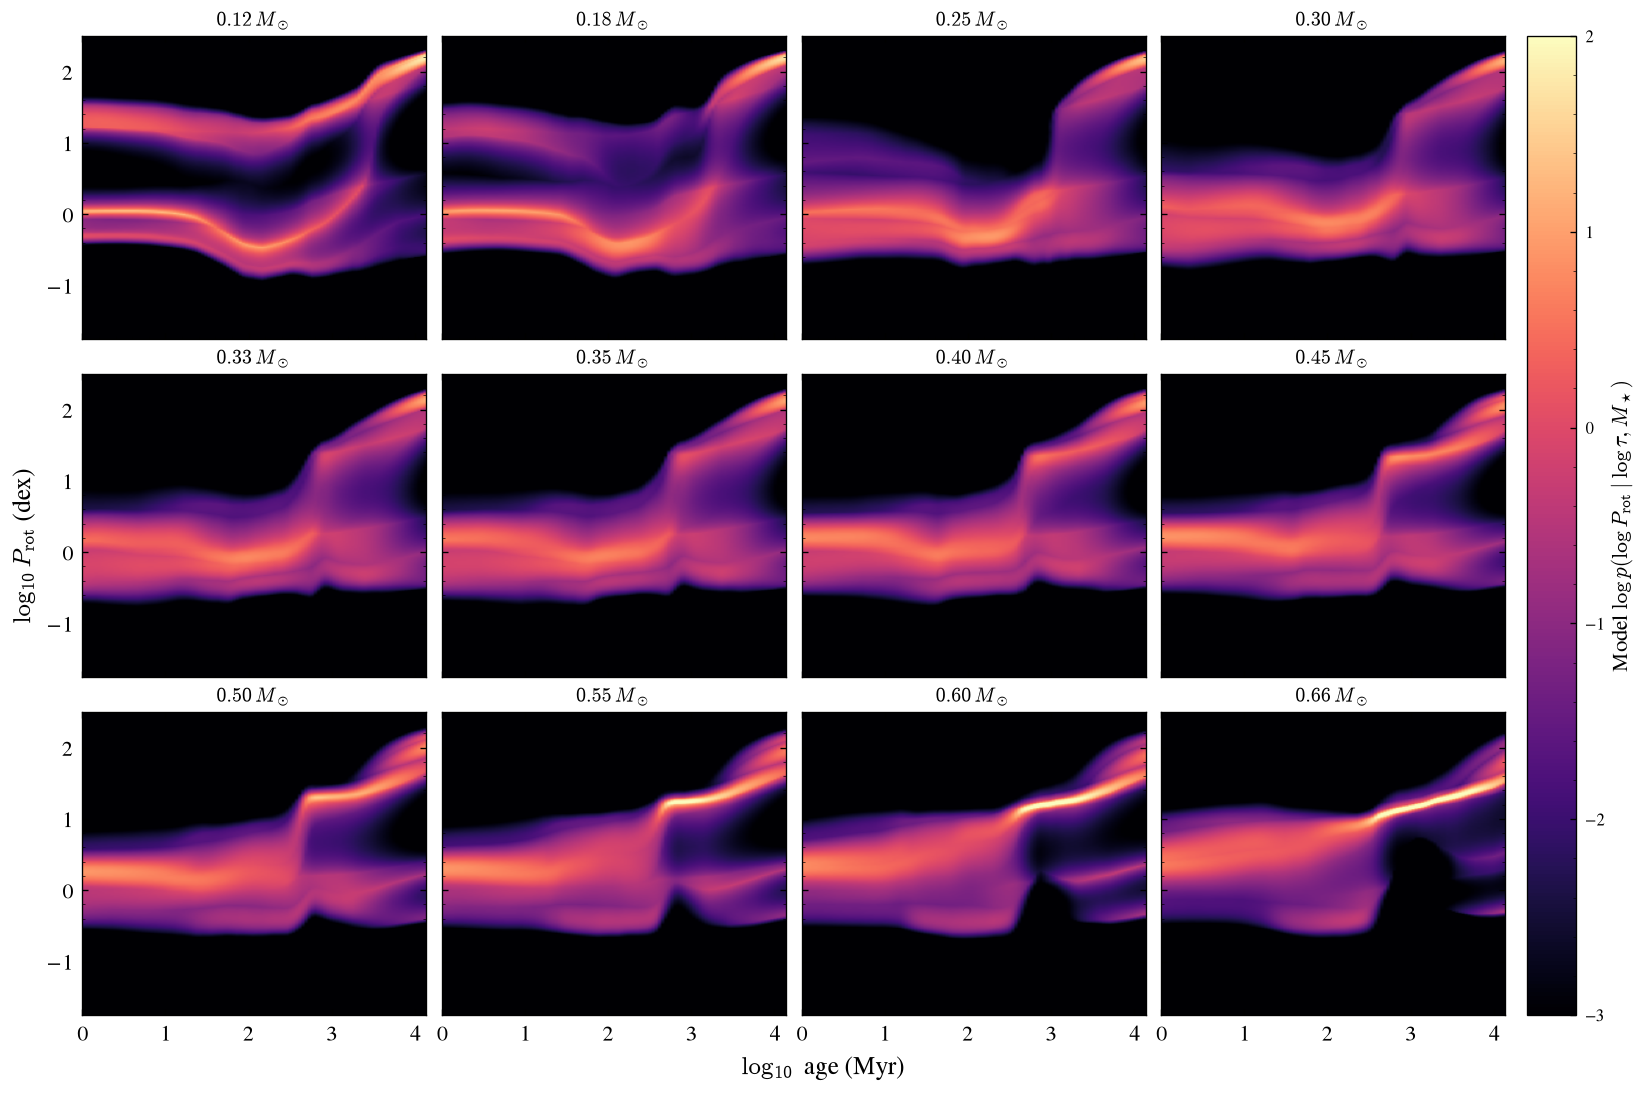

In [2]:
masses = [0.12, 0.18, 0.25, 0.30, 0.33, 0.35, 0.40, 0.45, 0.50, 0.55, 0.60, 0.66]
loga_myr = np.linspace(0.0, 4.14, 110)

fig, axes = plt.subplots(3, 4, figsize=(13.6, 9.0), sharex=True, sharey=True,
                         layout="constrained")
for ax, m in zip(axes.ravel(), masses):
    _, pdf = ef.prot_density(age_gyr=10 ** loga_myr / 1000, mass=m,
                             mass_err=mass_err, logprot_grid=prot_grid)
    im = ax.imshow(logdens(pdf), origin="lower", aspect="auto",
                   extent=[loga_myr[0], loga_myr[-1], prot_grid[0], prot_grid[-1]],
                   cmap="magma", vmin=-3, vmax=2)
    ax.set_title(rf"${m:.2f}\,M_\odot$", fontsize=12)
    ax.tick_params(labelsize=TICK_FS)
fig.supxlabel(r"$\log_{10}$ age (Myr)", fontsize=LABEL_FS)
fig.supylabel(r"$\log_{10} P_{\rm rot}$ (dex)", fontsize=LABEL_FS)
cbar = fig.colorbar(im, ax=axes.ravel().tolist(), pad=0.015,
                    label=r"Model $\log p(\log P_{\rm rot} \mid \log\tau, M_\star)$")
cbar.ax.tick_params(labelsize=10)

## Fixed age

This cell shows the learned density over mass and rotation period, at several
fixed ages. 

Useful for seeing how a coeval population of stars may behave depending on mass.

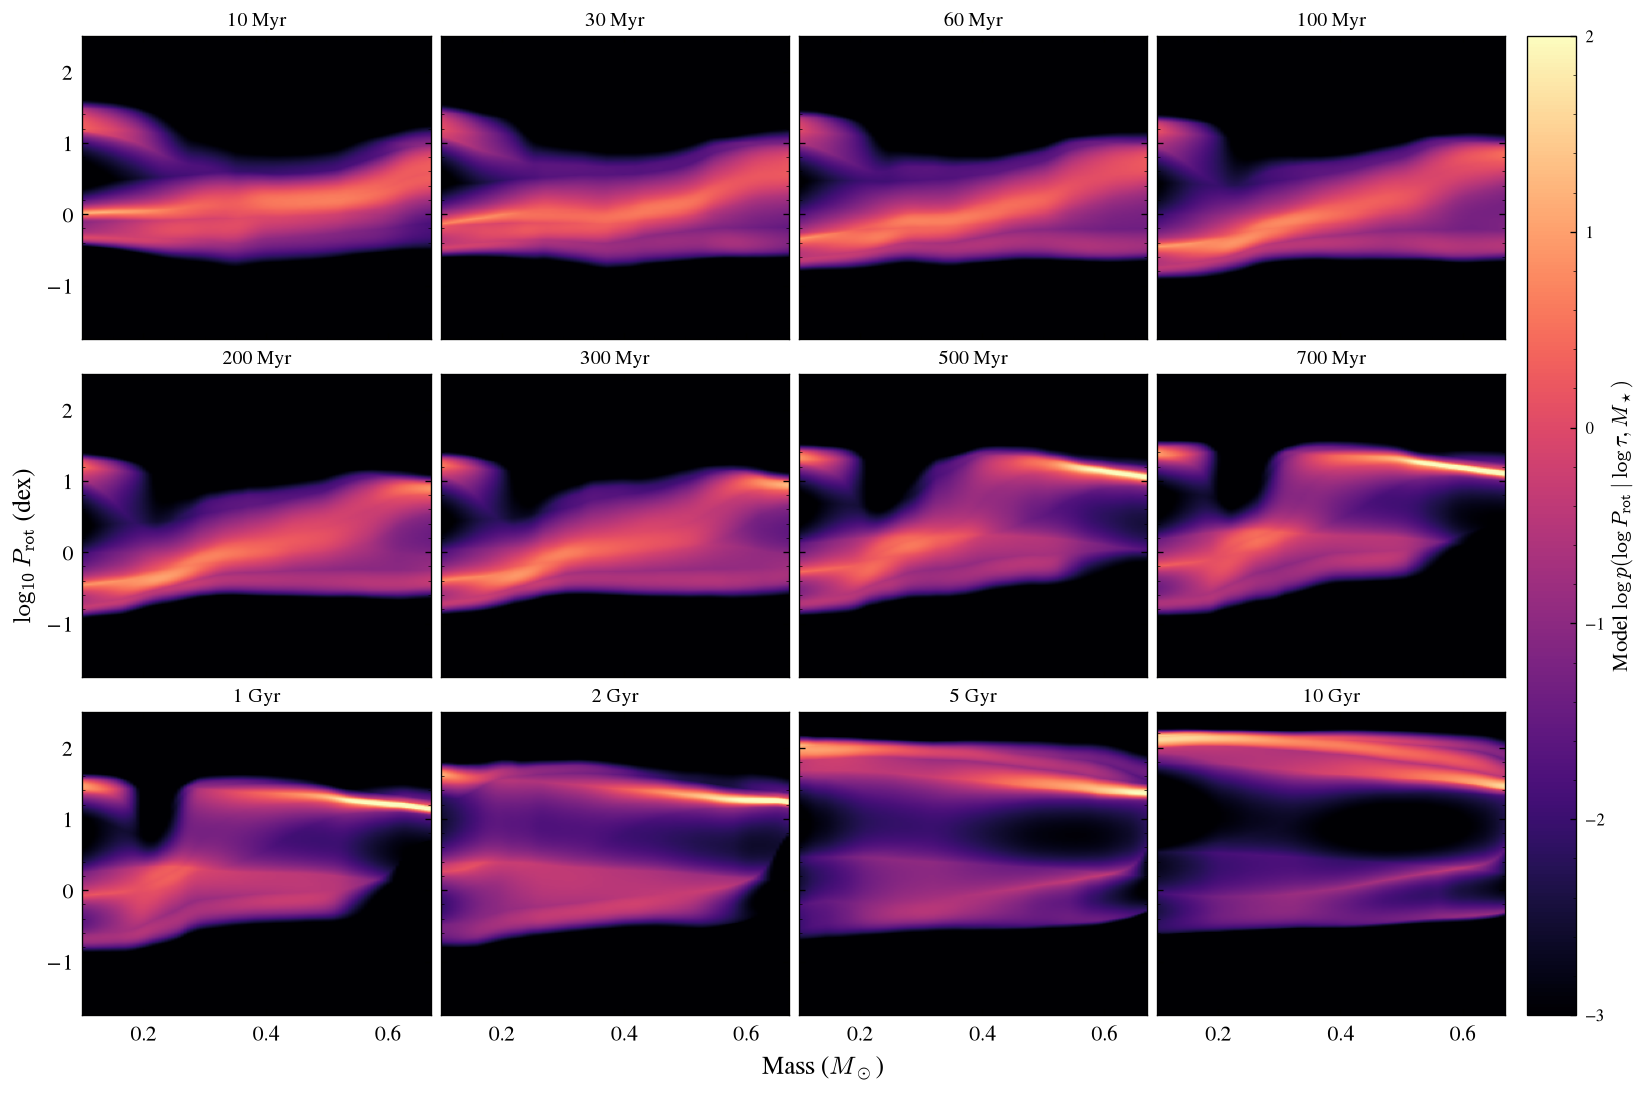

In [3]:
ages_myr = [10, 30, 60, 100, 200, 300, 500, 700, 1000, 2000, 5000, 10000]
mass_grid = np.linspace(0.10, 0.67, 110)

fig, axes = plt.subplots(3, 4, figsize=(13.6, 9.0), sharex=True, sharey=True,
                         layout="constrained")
for ax, a in zip(axes.ravel(), ages_myr):
    _, pdf = ef.prot_density(age_gyr=a / 1000, mass=mass_grid,
                             mass_err=mass_err, logprot_grid=prot_grid)
    im = ax.imshow(logdens(pdf), origin="lower", aspect="auto",
                   extent=[mass_grid[0], mass_grid[-1], prot_grid[0], prot_grid[-1]],
                   cmap="magma", vmin=-3, vmax=2)
    ax.set_title(f"{a} Myr" if a < 1000 else f"{a // 1000} Gyr", fontsize=12)
    ax.tick_params(labelsize=TICK_FS)
fig.supxlabel(r"Mass ($M_\odot$)", fontsize=LABEL_FS)
fig.supylabel(r"$\log_{10} P_{\rm rot}$ (dex)", fontsize=LABEL_FS)
cbar = fig.colorbar(im, ax=axes.ravel().tolist(), pad=0.015,
                    label=r"Model $\log p(\log P_{\rm rot} \mid \log\tau, M_\star)$")
cbar.ax.tick_params(labelsize=10)

## Sampling mock stars

`sample_prot` draws from the learned density, which basically reflects stars that perfectly follow it.

Useful for comparing the learned relationship against observed rotation periods, such as a cluster of stars (e.g. figure 10 of the paper)

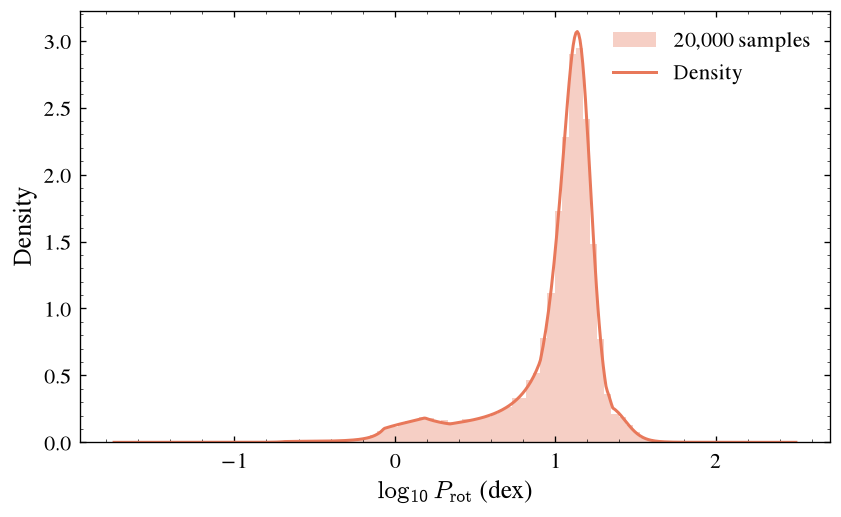

In [4]:
s = ef.sample_prot(age_gyr=0.7, mass=0.50, n=20000)
grid, pdf = ef.prot_density(age_gyr=0.7, mass=0.50)

fig, ax = plt.subplots(figsize=(6.9, 4.2), layout="constrained")
ax.hist(np.log10(s), bins=80, density=True, color=COLOR_ACCENT, alpha=0.35,
        label="20,000 samples")
ax.plot(grid, pdf, color=COLOR_ACCENT, lw=1.8, label="Density")
ax.set_xlabel(r"$\log_{10} P_{\rm rot}$ (dex)", fontsize=LABEL_FS)
ax.set_ylabel("Density", fontsize=LABEL_FS)
ax.tick_params(axis="both", which="major", labelsize=TICK_FS)
ax.legend(frameon=False, fontsize=TICK_FS)